## MACHINE LEARNING NOTEBOOK

#### This notebook aims to :
1. **Predict Customer Conversion:** Build a binary classification model to accurately predict whether an online shopping session will result in revenue (a purchase) or not.

2. **Identify Key Behavioral Drivers:** Analyze feature importances to determine which browsing metrics  impact a user's decision to buy the most.

3. **Optimize Model Performance:** Evaluate the model using precision, recall, and F1-score to ensure it handles the imbalanced nature of the dataset effectively and minimizes false positives.

### Importing necessary libraries

In [10]:
# 1. Standard Data Manipulation
import pandas as pd
import numpy as np

# 2. Visualization (for evaluating our model later)
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Scikit-Learn Machine Learning Ecosystem
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

### Loading the cleaned dataset 

In [11]:
# Read the CSV file
df = pd.read_csv('cleaned_online_shoppers_intention.csv')

# checking to ensure rows and columns loaded correctly
print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded successfully with 12330 rows and 18 columns.


## Data preprocessing

In [12]:
# 1. Isolate the target variable (Revenue) and convert True/False to 1/0
## True =1 and false = 0
y = df['Revenue'].astype(int)

# 2. Isolating the predictor features
X_raw = df.drop('Revenue', axis=1)

# 3. Convert categorical columns into numerical dummy variables
X = pd.get_dummies(X_raw, drop_first=True,dtype = int)

# 4. Preview the fully numerical features dataframe
X.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1


## Data Splitting and handling imbalance
 * From the data analysis, it shows the ratio of purchases to non purchases is 10422:1908 
 * This is about 0.85:0.15. The imbalance needs to be attended to


In [13]:
# Split the dataset 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20,       # 20% allocated to testing
    random_state=42,      # Ensures reproducible results every time you run it
    stratify=y            # Keeps the 15% vs 85% purchase ratio identical in both sets...
)

print(f"Training set size: {X_train.shape[0]} sessions")
print(f"Testing set size: {X_test.shape[0]} sessions")

Training set size: 9864 sessions
Testing set size: 2466 sessions


### Model Training (Random Forest)

In [14]:
# 1. Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42, 
                                  class_weight="balanced", 
                                  n_estimators = 150, ## increasing number of trees from default 100 to 150 
                                  max_depth= 12) ## Limits tree growth to 12 preventing over fitting

# 2. Fitting the model using only the training data
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### Model Evaluation

=================== MODEL PERFORMANCE ===================
              precision    recall  f1-score   support

           0       0.94      0.91      0.93      2084
           1       0.60      0.70      0.65       382

    accuracy                           0.88      2466
   macro avg       0.77      0.81      0.79      2466
weighted avg       0.89      0.88      0.88      2466



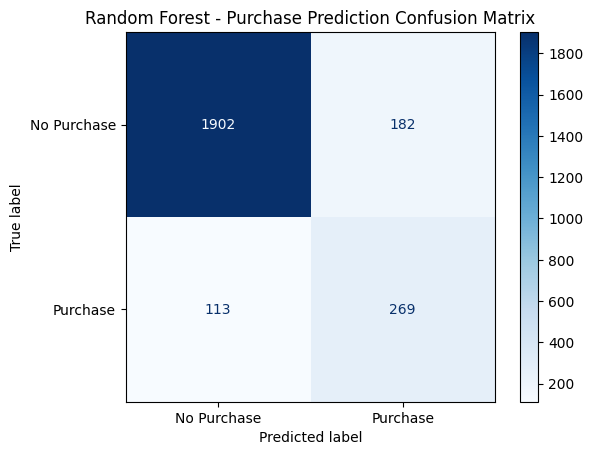

In [15]:
# 1. Generate predictions on the unseen test data
y_pred = rf_model.predict(X_test)

# 2. Print out the formal Classification Report (Precision, Recall, F1-Score)
print("=================== MODEL PERFORMANCE ===================")
print(classification_report(y_test, y_pred))

# 3. Generate and plot a visual Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Purchase', 'Purchase'])
disp.plot(cmap='Blues')

plt.title("Random Forest - Purchase Prediction Confusion Matrix")
plt.show()

C:\Users\Babji\AppData\Local\Temp\ipykernel_25992\3596798826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


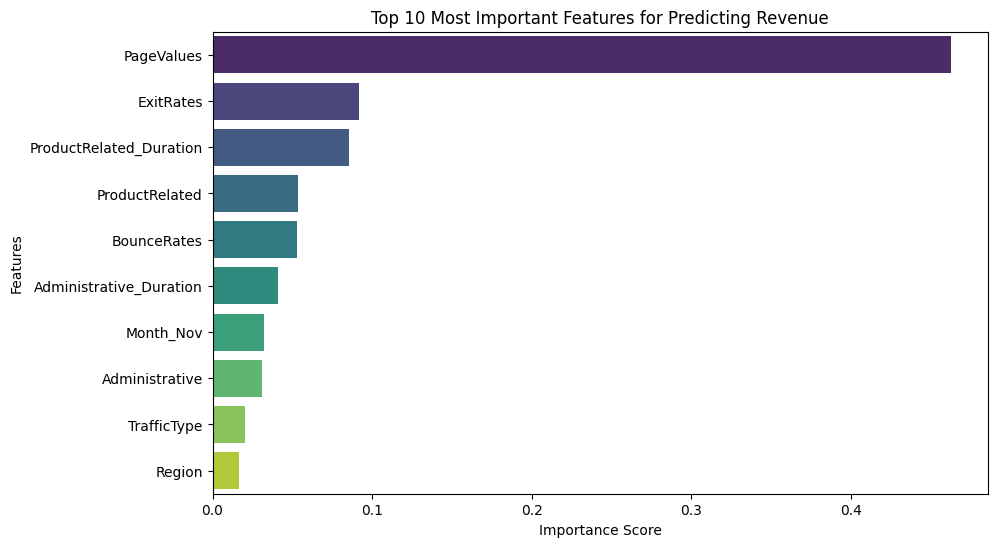

In [16]:
# Extract feature importances from your trained model
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a clean DataFrame to display them
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

# Plot the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Top 10 Most Important Features for Predicting Revenue')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

## OBSERVATION
 * Page values is the strongest feature affecting revenue
 * Most buyers are likely to spend more time on product related pages than administrative (log in /sign) in pages
 * The duration that a potential buyer interacts with on information (about, help) barely affects revenue


## Model Performance Analysis

The model achieved an overall accuracy of 88%, indicating strong general performance. However, given the class imbalance in the dataset (fewer buyers than non-buyers), accuracy alone is not a sufficient metric.

Focusing on the target class (buyers):

- **Recall (0.70)**: The model successfully identifies 70% of actual buyers. This is important from a business perspective, as it ensures that most potential customers are captured.

- **Precision (0.60)**: Out of all predicted buyers, 60% were actual buyers. This indicates that some non-buyers are incorrectly classified as buyers.

- **F1-score (0.65)**: The balance between precision and recall shows that the model performs reasonably well in identifying purchasing behavior.

The model prioritizes recall over precision, which is appropriate in this context. Missing a potential buyer represents a lost business opportunity, whereas incorrectly targeting a non-buyer has a lower cost.

Overall, the model demonstrates a strong ability to detect purchase intent, though there is room for improvement in reducing false positives.
